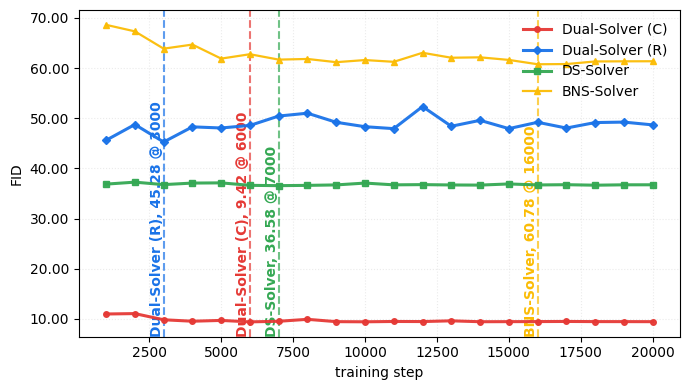

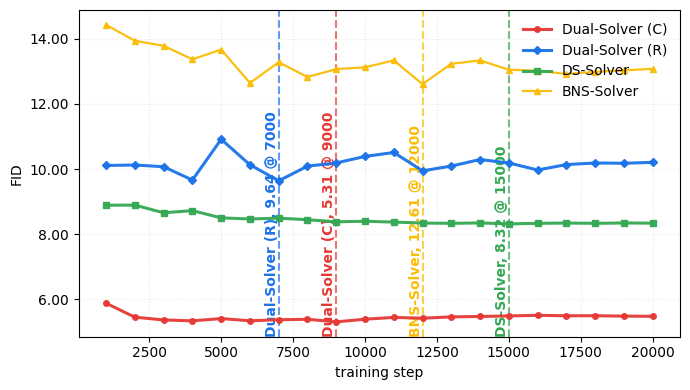

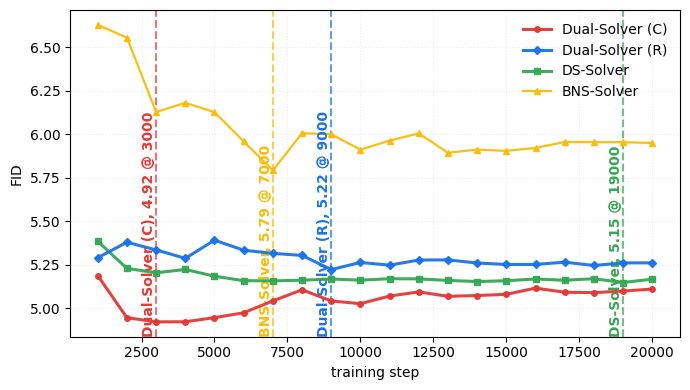

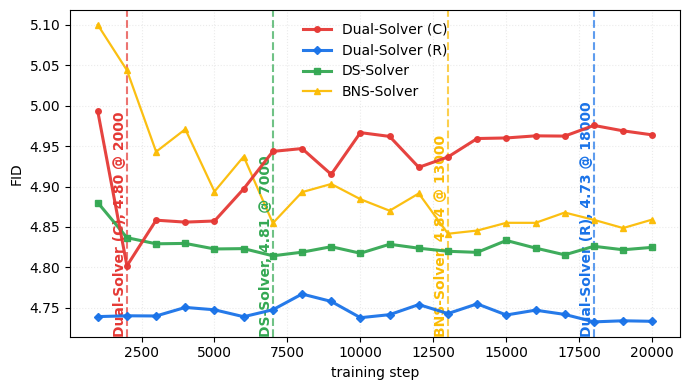

In [1]:
# Make vline labels bold for all four charts + add Dual-Solver (R) data
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter  # ← 추가

PALETTES = [
    ["#2962FF", "#FF3D00", "#00BFA5", "#AA00FF"],  # A700 quartet (블루/오렌지/틸/바이올렛)
    ["#007AFF", "#FF2D55", "#34C759", "#AF52DE"],  # iOS vivid (블루/코랄/그린/퍼플)
    ["#636EFA", "#EF553B", "#00CC96", "#AB63FA"],  # Plotly vivid (블루/레드오렌지/그린/라벤더)
    ["#1A73E8", "#E53935", "#34A853", "#FBBC05"],  # Google vivid (블루/레드/그린/앰버)
    ["#0057FF", "#FF6A00", "#00C853", "#D81B60"],  # 사파이어/오렌지/에메랄드/라즈베리
    ["#00A1FF", "#FF5A36", "#1BC47D", "#7A5FFF"],  # 시안/토마토/민트/바이올렛
    ["#0091EA", "#FF5252", "#00C853", "#6200EE"],  # 아쥬어/코랄/라임/퍼플
    ["#2E86DE", "#E67E22", "#10AC84", "#9B59B6"],  # 로열/오렌지/틸/아메시스트
    ["#0088FF", "#FF6D00", "#00BFA6", "#DB00FF"],  # 브라이트블루/앰버/틸그린/마젠타
    ["#00B0FF", "#FF9100", "#00E676", "#7C4DFF"],  # 라이트시안/오렌지/라임/퍼플
]
# 1, 3, 4
index = 3
style = {
    "Dual-Solver (C)": {"color": PALETTES[index][1], "lw": 2.2, "ls": "-",  "marker": "o", "zorder": 6},
    "Dual-Solver (R)": {"color": PALETTES[index][0], "lw": 2.2, "ls": "-",  "marker": "D", "zorder": 5},  # orange
    "DS-Solver":       {"color": PALETTES[index][2], "lw": 2.2, "ls": "-",  "marker": "s", "zorder": 4},
    "BNS-Solver":      {"color": PALETTES[index][3], "lw": 1.6, "ls": "-",  "marker": "^", "zorder": 3},
}

pts = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,11000,12000,13000,14000,15000,16000,17000,18000,19000,20000]

# --- Dual-Solver (C) (existing) ---
dual_3  = [10.9871,11.0676,9.836,9.5473,9.7076,9.4178,9.5371,9.9258,9.4617,9.4322,9.4967,9.481,9.626,9.4475,9.4628,9.4767,9.5007,9.4719,9.4678,9.4582]
dual_5  = [5.8811,5.4528,5.3677,5.3406,5.4099,5.3427,5.3743,5.3884,5.3089,5.3908,5.4459,5.4213,5.4619,5.4746,5.4912,5.5105,5.4962,5.4975,5.4851,5.4801]
dual_7  = [5.1873,4.9454,4.9215,4.9222,4.9457,4.9737,5.0419,5.1057,5.0416,5.0261,5.0698,5.0936,5.0683,5.0729,5.0796,5.1154,5.0915,5.0896,5.0984,5.1098]
dual_9  = [4.993,4.802,4.8584,4.856,4.8574,4.8971,4.9434,4.9469,4.915,4.9666,4.9619,4.9237,4.9365,4.9593,4.96,4.9626,4.9623,4.9755,4.9688,4.9638]

# --- BNS-Solver (existing) ---
bns_3 = [68.63200454,67.33378586,63.88437547,64.70093705,61.90316773,62.77671179,61.70102623,61.83202598,61.19011299,61.61379643,61.26226448,63.06354478,62.07559276,62.15704308,61.64160798,60.77722081,60.81508405,61.33476818,61.36167829,61.37582766]
bns_5 = [14.42500623,13.93579763,13.78241785,13.3674146,13.66636584,12.64095452,13.27666965,12.82490186,13.06678874,13.12224601,13.33421736,12.60529513,13.23012594,13.33296775,13.04748349,13.01867029,12.9159622,12.98306995,13.02940909,13.07293473]
bns_7 = [6.627314743,6.553685435,6.126509,6.179333242,6.125838259,5.957408765,5.791338757,6.004559158,5.999116188,5.910669015,5.962326981,6.004066326,5.892664218,5.910795526,5.903648371,5.920572383,5.954338547,5.953589516,5.953293133,5.948862776]
bns_9 = [5.099758772,5.043651174,4.942997827,4.970811234,4.893838313,4.93704942,4.854749008,4.893050468,4.903126507,4.884333994,4.870110559,4.891433379,4.841644105,4.845577568,4.855152782,4.855114976,4.867834637,4.858815434,4.84865587,4.859161133]

# --- DS-Solver (existing) ---
ds_3 = [36.881420903714684,37.272746305433884,36.779913440544306,37.08943230742102,37.1285678057755,36.63538561170651,36.57642265090266,36.62985203764117,36.722391672135984,37.08822955568621,36.73484501441692,36.779424419774614,36.71134535219329,36.684134431635414,36.91523733652707,36.71411722311518,36.764919510422885,36.665614515008315,36.74261018267839,36.74629456366074]
ds_5 = [8.890231636521492,8.891573571622757,8.657268224013706,8.723343440011263,8.500860937187326,8.466674193361314,8.491431032217577,8.443700600371926,8.380928657633149,8.396941042453477,8.371488842820895,8.342129073325168,8.33321762411282,8.345591122410497,8.316330548701728,8.33322696155318,8.342508522789672,8.332977378060093,8.344704664241362,8.339065888401592]
ds_7 = [5.384137671931853,5.228646194346879,5.203558426250083,5.222548009460695,5.1835874098806585,5.158111865040098,5.156990960137875,5.1608323148717545,5.167662274017459,5.1609601640312235,5.169425954300152,5.1682788344540995,5.159483586676515,5.153124915923286,5.157782783543325,5.167749289563062,5.160621004754262,5.169241186335682,5.14750458329047,5.166862017101323]
ds_9 = [4.880115123810526,4.83678462709446,4.829209550558119,4.829694490721408,4.822834144867841,4.823256837398617,4.814386437249198,4.818848723516908,4.825635831231978,4.817549980734441,4.828657424507526,4.823757818264767,4.819965627034605,4.818654006800159,4.833321199364093,4.823937501573994,4.815569817885773,4.826142319559551,4.821844619706212,4.824827167895705]

# --- Dual-Solver (R) (new; filled from your table) ---
dualR_3 = [45.62426272,48.76166133,45.27693905,48.29688566,48.0716305,48.58151834,50.45105616,51.01771198,49.20649567,48.32562607,47.94045498,52.34592208,48.41520393,49.59695795,47.94398011,49.20837482,48.05768337,49.15272944,49.24448455,48.68669285]
dualR_5 = [10.10834845,10.12325864,10.07025176,9.66214793,10.91145782,10.12990557,9.638762163,10.08842517,10.18663644,10.38688381,10.50769517,9.944355808,10.09092302,10.2915483,10.18610321,9.970294717,10.13665325,10.18570024,10.17671536,10.20565805]
dualR_7 = [5.290177652,5.378787037,5.3346752,5.286387858,5.390622872,5.333203021,5.314735294,5.30327818,5.221833421,5.262677571,5.247228532,5.276738574,5.277403926,5.259604708,5.251071016,5.251491337,5.264353514,5.24525587,5.259985341,5.260591876]
dualR_9 = [4.739246224,4.74026268,4.740035225,4.750606493,4.747675251,4.739113178,4.747732622,4.767172922,4.75800522,4.737908053,4.74165388,4.754116353,4.743011623,4.754983979,4.741247554,4.747202731,4.741962661,4.732745855,4.734092716,4.733434302]

models = {
    "Dual-Solver (C)": {3: dual_3, 5: dual_5, 7: dual_7, 9: dual_9},
    "Dual-Solver (R)": {3: dualR_3, 5: dualR_5, 7: dualR_7, 9: dualR_9},
    "DS-Solver":       {3: ds_3,    5: ds_5,    7: ds_7,    9: ds_9},
    "BNS-Solver":      {3: bns_3,   5: bns_5,   7: bns_7,   9: bns_9},
}
NFEs = [3,5,7,9]

def plot_for_nfe(nfe):
    fig, ax = plt.subplots(figsize=(7,4))
    colors = {}
    for label, series in models.items():
        st = style[label]
        (ln,) = ax.plot(
            pts, series[nfe],
            label=label, marker=st["marker"],
            linewidth=st["lw"], linestyle=st["ls"], color=st["color"],
            markersize=4, zorder=st["zorder"], alpha=0.95
        )
        colors[label] = ln.get_color()

    ax.set_xlabel("training step")
    ax.set_ylabel("FID")

    # y축 눈금도 소수 둘째자리로 표시
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    ax.grid(True, alpha=0.25, linestyle=":")
    ax.legend(frameon=False, loc="best")

    ymin, ymax = ax.get_ylim()

    # Bold labels on vlines for all four charts
    for label, series in models.items():
        vals = series[nfe]
        i = min(range(len(vals)), key=lambda k: vals[k])
        min_pt, min_val = pts[i], vals[i]
        c = colors[label]
        ax.axvline(min_pt, linestyle="--", color=c, alpha=0.7)
        ax.text(
            min_pt, ymin, f"{label}, {min_val:.2f} @ {min_pt}",  # ← .2f 로 변경
            rotation=90, va="bottom", ha="right",
            fontsize=10, color=c, fontweight="bold"
        )
    fig.tight_layout()

for nfe in NFEs:
    plot_for_nfe(nfe)


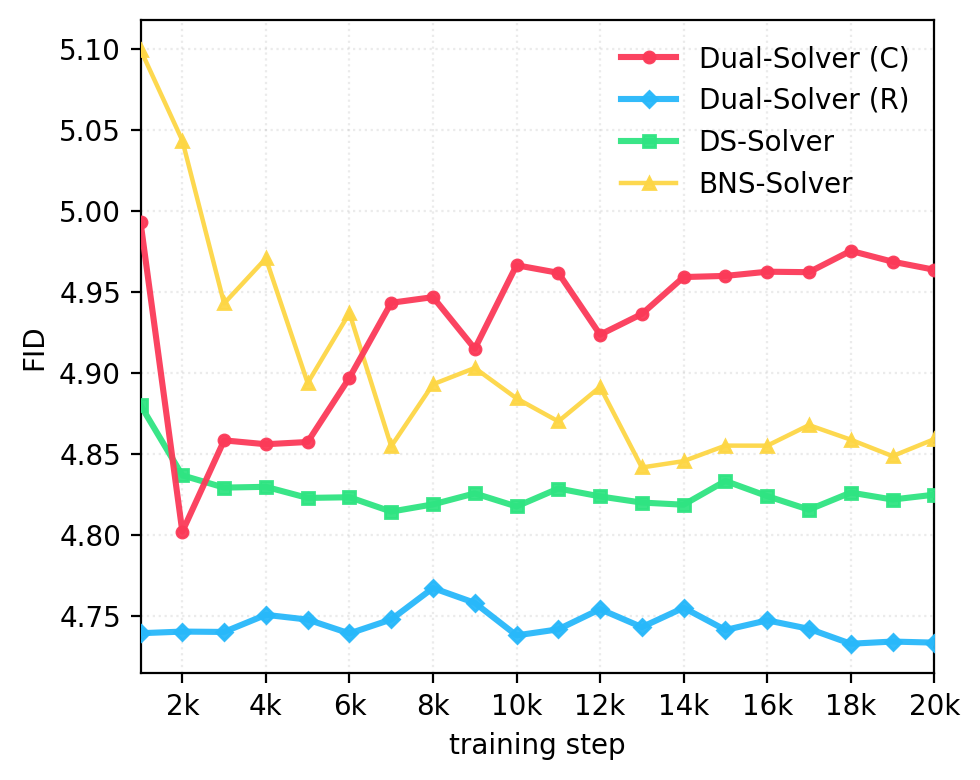

In [3]:
# Make vline labels bold for all four charts + add Dual-Solver (R) data
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter, MultipleLocator, FuncFormatter

PALETTES = ["#28B8FA", "#FB3A58", "#2FE482", "#FDD645",]
style = {
    "Dual-Solver (C)": {"color": PALETTES[1], "lw": 2.2, "ls": "-",  "marker": "o", "zorder": 6},
    "Dual-Solver (R)": {"color": PALETTES[0], "lw": 2.2, "ls": "-",  "marker": "D", "zorder": 5},  # orange
    "DS-Solver":       {"color": PALETTES[2], "lw": 2.2, "ls": "-",  "marker": "s", "zorder": 4},
    "BNS-Solver":      {"color": PALETTES[3], "lw": 1.6, "ls": "-",  "marker": "^", "zorder": 3},
}

pts = [1000,2000,3000,4000,5000,6000,7000,8000,9000,10000,11000,12000,13000,14000,15000,16000,17000,18000,19000,20000]

# --- Dual-Solver (C) (existing) ---
dual_3  = [10.9871,11.0676,9.836,9.5473,9.7076,9.4178,9.5371,9.9258,9.4617,9.4322,9.4967,9.481,9.626,9.4475,9.4628,9.4767,9.5007,9.4719,9.4678,9.4582]
dual_5  = [5.8811,5.4528,5.3677,5.3406,5.4099,5.3427,5.3743,5.3884,5.3089,5.3908,5.4459,5.4213,5.4619,5.4746,5.4912,5.5105,5.4962,5.4975,5.4851,5.4801]
dual_7  = [5.1873,4.9454,4.9215,4.9222,4.9457,4.9737,5.0419,5.1057,5.0416,5.0261,5.0698,5.0936,5.0683,5.0729,5.0796,5.1154,5.0915,5.0896,5.0984,5.1098]
dual_9  = [4.993,4.802,4.8584,4.856,4.8574,4.8971,4.9434,4.9469,4.915,4.9666,4.9619,4.9237,4.9365,4.9593,4.96,4.9626,4.9623,4.9755,4.9688,4.9638]

# --- BNS-Solver (existing) ---
bns_3 = [68.63200454,67.33378586,63.88437547,64.70093705,61.90316773,62.77671179,61.70102623,61.83202598,61.19011299,61.61379643,61.26226448,63.06354478,62.07559276,62.15704308,61.64160798,60.77722081,60.81508405,61.33476818,61.36167829,61.37582766]
bns_5 = [14.42500623,13.93579763,13.78241785,13.3674146,13.66636584,12.64095452,13.27666965,12.82490186,13.06678874,13.12224601,13.33421736,12.60529513,13.23012594,13.33296775,13.04748349,13.01867029,12.9159622,12.98306995,13.02940909,13.07293473]
bns_7 = [6.627314743,6.553685435,6.126509,6.179333242,6.125838259,5.957408765,5.791338757,6.004559158,5.999116188,5.910669015,5.962326981,6.004066326,5.892664218,5.910795526,5.903648371,5.920572383,5.954338547,5.953589516,5.953293133,5.948862776]
bns_9 = [5.099758772,5.043651174,4.942997827,4.970811234,4.893838313,4.93704942,4.854749008,4.893050468,4.903126507,4.884333994,4.870110559,4.891433379,4.841644105,4.845577568,4.855152782,4.855114976,4.867834637,4.858815434,4.84865587,4.859161133]

# --- DS-Solver (existing) ---
ds_3 = [36.881420903714684,37.272746305433884,36.779913440544306,37.08943230742102,37.1285678057755,36.63538561170651,36.57642265090266,36.62985203764117,36.722391672135984,37.08822955568621,36.73484501441692,36.779424419774614,36.71134535219329,36.684134431635414,36.91523733652707,36.71411722311518,36.764919510422885,36.665614515008315,36.74261018267839,36.74629456366074]
ds_5 = [8.890231636521492,8.891573571622757,8.657268224013706,8.723343440011263,8.500860937187326,8.466674193361314,8.491431032217577,8.443700600371926,8.380928657633149,8.396941042453477,8.371488842820895,8.342129073325168,8.33321762411282,8.345591122410497,8.316330548701728,8.33322696155318,8.342508522789672,8.332977378060093,8.344704664241362,8.339065888401592]
ds_7 = [5.384137671931853,5.228646194346879,5.203558426250083,5.222548009460695,5.1835874098806585,5.158111865040098,5.156990960137875,5.1608323148717545,5.167662274017459,5.1609601640312235,5.169425954300152,5.1682788344540995,5.159483586676515,5.153124915923286,5.157782783543325,5.167749289563062,5.160621004754262,5.169241186335682,5.14750458329047,5.166862017101323]
ds_9 = [4.880115123810526,4.83678462709446,4.829209550558119,4.829694490721408,4.822834144867841,4.823256837398617,4.814386437249198,4.818848723516908,4.825635831231978,4.817549980734441,4.828657424507526,4.823757818264767,4.819965627034605,4.818654006800159,4.833321199364093,4.823937501573994,4.815569817885773,4.826142319559551,4.821844619706212,4.824827167895705]

# --- Dual-Solver (R) (new; filled from your table) ---
dualR_3 = [45.62426272,48.76166133,45.27693905,48.29688566,48.0716305,48.58151834,50.45105616,51.01771198,49.20649567,48.32562607,47.94045498,52.34592208,48.41520393,49.59695795,47.94398011,49.20837482,48.05768337,49.15272944,49.24448455,48.68669285]
dualR_5 = [10.10834845,10.12325864,10.07025176,9.66214793,10.91145782,10.12990557,9.638762163,10.08842517,10.18663644,10.38688381,10.50769517,9.944355808,10.09092302,10.2915483,10.18610321,9.970294717,10.13665325,10.18570024,10.17671536,10.20565805]
dualR_7 = [5.290177652,5.378787037,5.3346752,5.286387858,5.390622872,5.333203021,5.314735294,5.30327818,5.221833421,5.262677571,5.247228532,5.276738574,5.277403926,5.259604708,5.251071016,5.251491337,5.264353514,5.24525587,5.259985341,5.260591876]
dualR_9 = [4.739246224,4.74026268,4.740035225,4.750606493,4.747675251,4.739113178,4.747732622,4.767172922,4.75800522,4.737908053,4.74165388,4.754116353,4.743011623,4.754983979,4.741247554,4.747202731,4.741962661,4.732745855,4.734092716,4.733434302]

models = {
    "Dual-Solver (C)": {3: dual_3, 5: dual_5, 7: dual_7, 9: dual_9},
    "Dual-Solver (R)": {3: dualR_3, 5: dualR_5, 7: dualR_7, 9: dualR_9},
    "DS-Solver":       {3: ds_3,    5: ds_5,    7: ds_7,    9: ds_9},
    "BNS-Solver":      {3: bns_3,   5: bns_5,   7: bns_7,   9: bns_9},
}
NFEs = [3,5,7,9]

def plot_for_nfe(nfe):
    fig, ax = plt.subplots(figsize=(5,4), dpi=200)
    colors = {}
    for label, series in models.items():
        st = style[label]
        (ln,) = ax.plot(
            pts, series[nfe],
            label=label, marker=st["marker"],
            linewidth=st["lw"], linestyle=st["ls"], color=st["color"],
            markersize=4, zorder=st["zorder"], alpha=0.95
        )
        colors[label] = ln.get_color()

    ax.set_xlabel("training step")
    ax.set_ylabel("FID")
    ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    ax.grid(True, alpha=0.25, linestyle=":")
    ax.legend(frameon=False, loc="best")

    # --- X축을 2k 간격으로 표시 ---
    ax.set_xlim(min(pts), max(pts))
    ax.xaxis.set_major_locator(MultipleLocator(2000))        # 2000, 4000, ..., 20000
    # 숫자를 '2k', '4k'처럼 보이게 하려면 아래 주석을 해제하세요.
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{int(x/1000)}k"))

    fig.tight_layout()

plot_for_nfe(9)
